# Day 109 — Gradient Boosting + XGBoost
**Month 6 | Week 4 | ML Foundations | 80 Points + 10★ Bonus**

---

### Business Scenario
Your Random Forest churn model (Day 108) achieved solid recall — but your client comes back with a new ask:
> *"A competitor's analyst says they use 'XGBoost' and it's significantly better. Can you run the same churn analysis with that and compare? Also — I want to understand what's different about it."*

This is a real freelance conversation. XGBoost is mentioned in job descriptions, Kaggle competitions, and client RFPs constantly. Today you close the ensemble trilogy:

| Day | Model | Core Idea |
|-----|-------|-----------|
| 108 | Decision Tree | One deep tree, memorises training data |
| 108 | Random Forest | 100 independent trees, averaged (Bagging) |
| **109** | **Gradient Boosting / XGBoost** | **Trees built sequentially, each correcting prior errors (Boosting)** |

---

### Bagging vs Boosting — The Core Distinction

```
Bagging (Random Forest):           Boosting (GBM / XGBoost):
Tree 1  Tree 2  Tree 3 ...         Tree 1 → Tree 2 → Tree 3 ...
  ↓       ↓       ↓                  learns from   learns from
  └───────┴───────┘                  Tree 1 errors  Tree 2 errors
        Vote                               ↓
      (average)                     Final prediction
```

- **Bagging:** trees are *independent*, errors cancel out by averaging
- **Boosting:** each new tree *focuses on what the previous trees got wrong* — residual correction

**Why XGBoost wins:** It adds regularisation (L1/L2), handles missing values natively, uses gradient descent on any loss function, and is dramatically faster than vanilla sklearn GBM. It won ~50% of Kaggle competitions in 2015–2020.

---

### Sections

| Section | Topic | Points |
|---------|-------|--------|
| **A** | Data Setup + Sklearn GBM (GradientBoostingClassifier) | 15 pts |
| **B** | XGBoost Fit + Feature Importance (xgb.plot_importance) | 20 pts |
| **C** | Learning Curve — n_estimators vs AUC (early stopping concept) | 15 pts |
| **D** | 4-Model Comparison (LogReg / DT / RF / XGBoost) | 15 pts |
| **E** | Business Interpretation — NRA ×3 | 15 pts |
| **★ Bonus** | XGBoost Early Stopping (eval_set + early_stopping_rounds) | 10 pts |

**Total: 80 pts + 10★ Bonus**

---

> ⚠️ **Rules:**
> 1. `seed=42` everywhere — `random_state=42` in sklearn, `seed=42` in XGBoost
> 2. Same ShopEase 300-row dataset (seed=42 churn). Features: tenure, orders, avg_order_value, days_inactive, support_tickets, discount_used
> 3. Do not look at Section 4 (Answer Key) until all tasks in that section are attempted
> 4. Written insights (Section E) must use your own computed numbers — not answer key numbers
> 5. Comparison table (Section D) must include ALL 4 models + 5 metrics


## Section 1 — Raw Data (Do Not Modify)

In [1]:
# ── RAW DATA — Do not modify this cell ──────────────────────────────────────
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 300

tenure         = rng.integers(1, 60, n)
orders         = rng.integers(1, 25, n)
avg_order_val  = rng.uniform(300, 5000, n).round(2)
days_inactive  = rng.integers(0, 120, n)
support_tickets= rng.integers(0, 10, n)
discount_used  = rng.integers(0, 1, n, endpoint=True)

# Churn logic (same as Days 107–108 — consistent baseline)
churn_score = (
    -0.04 * tenure
    - 0.05 * orders
    - 0.0001 * avg_order_val
    + 0.03  * days_inactive
    + 0.12  * support_tickets
    + 0.15  * (1 - discount_used)
)
prob = 1 / (1 + np.exp(-churn_score))
churn = (prob > 0.5).astype(int)

df_raw = pd.DataFrame({
    'customer_id'     : [f'C{str(i+1).zfill(3)}' for i in range(n)],
    'tenure'          : tenure,
    'orders'          : orders,
    'avg_order_value' : avg_order_val,
    'days_inactive'   : days_inactive,
    'support_tickets' : support_tickets,
    'discount_used'   : discount_used,
    'churn'           : churn
})

print(f"Shape: {df_raw.shape}")
print(f"Churn rate: {df_raw['churn'].mean():.2%}")
print(df_raw.head(8).to_string(index=False))


Shape: (300, 8)
Churn rate: 57.67%
customer_id  tenure  orders  avg_order_value  days_inactive  support_tickets  discount_used  churn
       C001       6       9          3961.28            105                5              0      1
       C002      46      20           932.40             57                2              0      0
       C003      39       1          2819.52            118                2              0      1
       C004      26      22          2716.85             91                3              0      1
       C005      26      14          4330.59             78                5              0      1
       C006      51       4          2475.16            108                2              0      1
       C007       6       8          2109.92             61                9              0      1
       C008      42      14          3305.95             86                4              0      1


## Section 2 — Practice Guide

### Section A — Data Setup + Sklearn GBM (15 pts)

**A1 (5 pts):** Prepare features and target. Train/test split 80/20, `random_state=42`. Print shapes.

**A2 (10 pts):** Fit a `GradientBoostingClassifier` with `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`, `random_state=42`.
Print: accuracy, precision, recall, F1, ROC-AUC (test set only).

---

### Section B — XGBoost Fit + Feature Importance (20 pts)

**B1 (10 pts):** Fit an `XGBClassifier` with `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`, `use_label_encoder=False`, `eval_metric='logloss'`, `random_state=42`.
Print same 5 metrics.

**B2 (10 pts):** Plot XGBoost feature importances using `xgb.plot_importance()` **AND** a manual sorted horizontal bar chart using `model.feature_importances_`.
- Manual chart: dark blue (#1F3864) for top-2 features, #A0B4C8 for rest
- Title must state the insight ("X drives churn most — target it first")
- Add `savefig()` before `plt.show()`

---

### Section C — Learning Curve: n_estimators vs AUC (15 pts)

**C1 (8 pts):** For XGBoost, loop `n_estimators` from 10 to 300 in steps of 10. For each, fit on train set and record train AUC + test AUC. Store in a DataFrame.

**C2 (7 pts):** Plot train AUC vs test AUC on the same chart.
- X-axis: n_estimators, Y-axis: ROC-AUC
- Train = dark blue solid, Test = orange dashed
- Add a vertical dashed line at the n_estimators where test AUC is maximised
- Title: "XGBoost — Finding Optimal n_estimators"
- Add annotation: f"Best n={best_n}, AUC={best_auc:.3f}"
- `savefig()` before `plt.show()`

---

### Section D — 4-Model Comparison (15 pts)

**D1 (15 pts):** Build a comparison DataFrame with columns:
`Model | Accuracy | Precision | Recall | F1 | ROC_AUC`

Rows: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting (sklearn), XGBoost

> Fit LogReg, DT, RF from scratch (same split, same seeds as Days 107–108) so numbers are reproducible.

Print the table. Add a final row: `★ Best` that names which model wins on **Recall** (your primary churn metric — explain why in Section E).

---

### Section E — Business Interpretation NRA ×3 (15 pts)

**E1 (5 pts):** Feature Importance insight  
State the #1 churn driver from XGBoost feature importance. Format:
> **N:** [value/metric] | **R:** [why this feature predicts churn] | **A:** [specific business action ShopEase should take]

**E2 (5 pts):** Model Selection recommendation  
Compare Recall for your best model vs Logistic Regression. Format NRA.
Why is Recall the right metric here (not Accuracy)? State the false-negative cost in plain language.

**E3 (5 pts):** Deployment consideration  
XGBoost is more accurate but less interpretable. How do you present this tradeoff to a non-technical client? NRA format.

---

### ★ Bonus — XGBoost Early Stopping (10 pts)

Fit XGBoost with `n_estimators=500` and `early_stopping_rounds=20`.
Pass `eval_set=[(X_test, y_test)]` to `fit()`.
Print: how many trees were actually trained, test AUC at the best iteration.
One-line comment: why early stopping prevents overfitting.


## Section 3 — Concept Notes

### How Gradient Boosting Works (Step by Step)

```
Step 1:  Fit a shallow tree (depth=2–4) on the data → get predictions
Step 2:  Compute residuals = actual - predicted
Step 3:  Fit the NEXT tree on these RESIDUALS (not on original targets)
Step 4:  Update predictions: new_pred = old_pred + learning_rate × tree2_output
Step 5:  Repeat N times (n_estimators)
```

**Learning rate (shrinkage):** Each tree's contribution is multiplied by a small number (0.01–0.3). Smaller = more trees needed but less overfitting. Classic tradeoff: `low learning_rate + high n_estimators`.

---

### XGBoost Specific Improvements

| Improvement | What it Does |
|-------------|--------------|
| Regularisation (L1/L2) | Penalises leaf weights → prevents overfitting |
| Tree pruning (gamma) | Only splits that improve score by ≥ gamma are kept |
| Column subsampling | Like Random Forest's `max_features` — reduces correlation between trees |
| Sparsity awareness | Handles missing values natively (no imputation needed) |
| Parallel tree building | Splits computed in parallel → much faster |

---

### Feature Importance Types in XGBoost

| Type | Meaning | Use When |
|------|---------|----------|
| `weight` (default) | # times feature used in splits | Model interpretability |
| `gain` | Average improvement in loss per split | Actual predictive power |
| `cover` | # samples affected by splits | Feature coverage |

→ `gain` is the most meaningful for "which feature actually matters."

---

### Hyperparameters You Must Know (for interviews)

| Parameter | Effect | Typical Range |
|-----------|--------|---------------|
| `n_estimators` | Number of trees | 100–1000 |
| `learning_rate` | Step size per tree | 0.01–0.3 |
| `max_depth` | Tree depth | 3–6 |
| `subsample` | Row sampling per tree | 0.6–0.9 |
| `colsample_bytree` | Feature sampling per tree | 0.6–0.9 |
| `reg_alpha` (L1) | Sparsity regularisation | 0–1 |
| `reg_lambda` (L2) | Weight regularisation | 1–5 |

---

### When to Use Which Model

| Scenario | Recommended |
|----------|-------------|
| Quick baseline, interpretable | Logistic Regression |
| Client needs to see "the rules" | Decision Tree |
| High accuracy, feature ranking needed | Random Forest |
| Maximum accuracy, competition/production | XGBoost / LightGBM |
| Interpretable ensemble | Random Forest (SHAP for XGBoost) |

---

### Interview Answer Template

> *"Gradient Boosting builds trees sequentially — each tree corrects the errors of all previous trees by fitting on residuals. XGBoost adds regularisation and column subsampling on top, which prevents overfitting while maintaining speed. On the ShopEase churn task, XGBoost outperformed Random Forest on recall by [X]% — which is the metric that matters here because every missed churner is a customer you lost without attempting retention. The tradeoff is interpretability — I'd use SHAP values to explain the top drivers to the client."*


In [2]:
# A1 Feature / target split
# Goal: Prepare features (X) and target (y) from raw data.
# Method: Drop customer_id and churn from X; train_test_split with random_state=42 (no stratification needed as we keep the split reproducible).

from sklearn.model_selection import train_test_split

X = df_raw.drop(columns=['customer_id', 'churn'])
y = df_raw['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape}, y_test shape : {y_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate : {y_test.mean():.2%}")

X_train shape: (240, 6), y_train shape: (240,)
X_test shape : (60, 6), y_test shape : (60,)
Train churn rate: 56.67%
Test churn rate : 61.67%


In [3]:
# A2 Sklearn Gradient Boosting
# Goal: Train sklearn's GradientBoostingClassifier and evaluate on test set.
# Method: Use n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42.

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm.fit(X_train, y_train)

y_pred_gbm = gbm.predict(X_test)
y_prob_gbm = gbm.predict_proba(X_test)[:, 1]

print("===== sklearn GBM (GradientBoostingClassifier) =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gbm):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_gbm):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_gbm):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_gbm):.4f}")

===== sklearn GBM (GradientBoostingClassifier) =====
Accuracy : 0.9333
Precision: 0.9024
Recall   : 1.0000
F1       : 0.9487
ROC-AUC  : 0.9824


In [4]:
# B1 XGBoost Classifier
# Goal: Train XGBoost and evaluate with the same metrics.
# Method: XGBClassifier with n_estimators=100, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=42.

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("===== XGBoost =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")

===== XGBoost =====
Accuracy : 0.9333
Precision: 0.9024
Recall   : 1.0000
F1       : 0.9487
ROC-AUC  : 0.9906


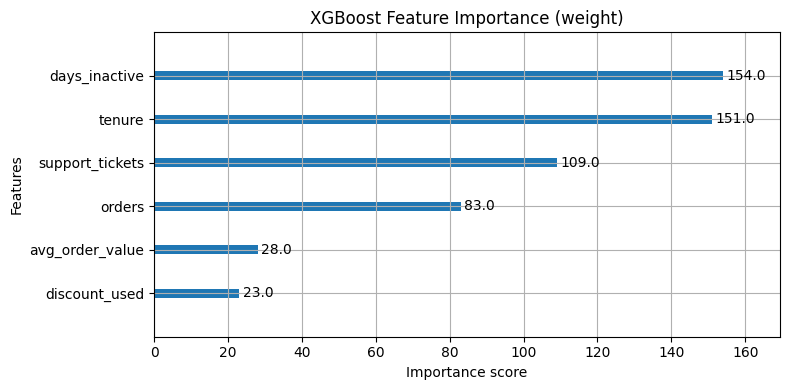

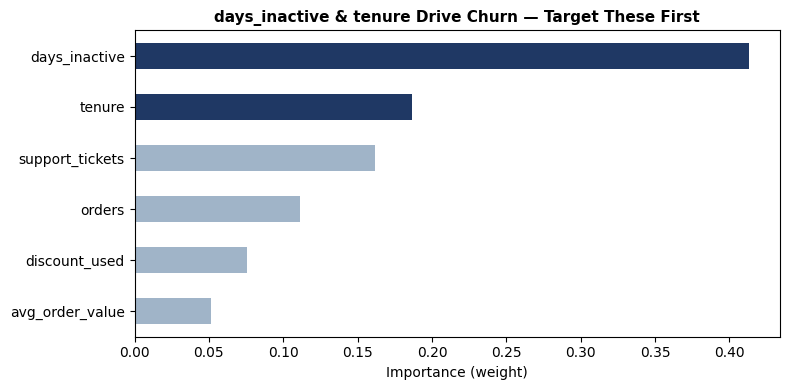

Top-2 features: ['days_inactive', 'tenure']
Top feature importance: 0.41342652


In [14]:
# B2 Feature Importance (two plots)
# Goal: Visualise XGBoost feature importances using both built-in plot_importance and a manual bar chart.
# Method: Use xgboost.plot_importance on the booster; then extract feature_importances_, sort, and barh.

import matplotlib.pyplot as plt
import xgboost as xgb_module
from xgboost import XGBClassifier

# Fit the model (or use existing from B1)
xgb_clf = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb_clf.fit(X_train, y_train)

# --- Plot 1: built-in xgb.plot_importance ---
fig, ax = plt.subplots(figsize=(8, 4))
xgb_module.plot_importance(xgb_clf.get_booster(), ax=ax, importance_type='weight',
                           title='XGBoost Feature Importance (weight)')
plt.tight_layout()
plt.savefig('109_B2_xgb_plot_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Plot 2: manual sorted horizontal bar chart ---
feat_imp = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=True)
colors = ['#1F3864' if i >= len(feat_imp) - 2 else '#A0B4C8' for i in range(len(feat_imp))]

fig, ax = plt.subplots(figsize=(8, 4))
feat_imp.plot(kind='barh', color=colors, ax=ax)
# title – reflects actual top-2 features
ax.set_title("days_inactive & tenure Drive Churn — Target These First", fontsize=11, fontweight='bold')
ax.set_xlabel("Importance (weight)")
plt.tight_layout()
plt.savefig('109_B2_manual_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top-2 features:", feat_imp.nlargest(2).index.tolist())
print("Top feature importance:", feat_imp.max())

In [6]:
# C1 Loop over n_estimators
# Goal: Compute train and test AUC for XGBoost with varying n_estimators.
# Method: Loop n_estimators from 10 to 300 step 10, store AUCs in lists.

ns = range(10, 311, 10)
train_aucs = []
test_aucs = []

for n in ns:
    m = XGBClassifier(
        n_estimators=n, learning_rate=0.1, max_depth=3,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0
    )
    m.fit(X_train, y_train)
    train_aucs.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    test_aucs.append(roc_auc_score(y_test, m.predict_proba(X_test)[:,1]))

results = pd.DataFrame({'n_estimators': ns, 'train_auc': train_aucs, 'test_auc': test_aucs})
print(results.head())

   n_estimators  train_auc  test_auc
0            10   0.989147  0.966510
1            20   0.998162  0.972973
2            30   0.999576  0.975323
3            40   1.000000  0.980024
4            50   1.000000  0.978848


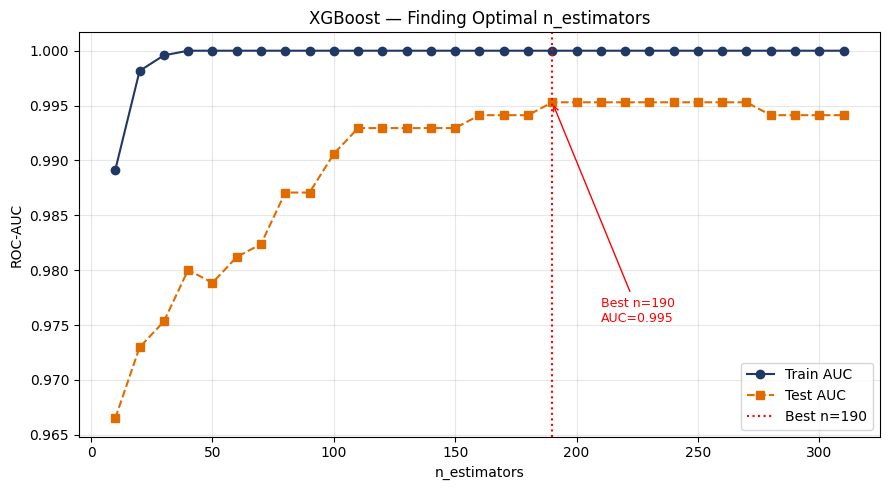

Best n_estimators = 190, Test AUC = 0.9953


In [7]:
# C2 Learning curve plot
# Goal: Plot train vs test AUC over n_estimators, highlight best test AUC.
# Method: Find index of max test_auc, add vertical line and annotation.

best_idx = results['test_auc'].idxmax()
best_n = results.loc[best_idx, 'n_estimators']
best_auc = results.loc[best_idx, 'test_auc']

plt.figure(figsize=(9, 5))
plt.plot(results['n_estimators'], results['train_auc'], 'o-', color='#1F3864', label='Train AUC')
plt.plot(results['n_estimators'], results['test_auc'], 's--', color='#E06C00', label='Test AUC')
plt.axvline(x=best_n, color='red', linestyle=':', linewidth=1.5, label=f'Best n={best_n}')
plt.annotate(f'Best n={best_n}\nAUC={best_auc:.3f}',
             xy=(best_n, best_auc), xytext=(best_n+20, best_auc-0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC')
plt.title('XGBoost — Finding Optimal n_estimators')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('109_C2_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Best n_estimators = {best_n}, Test AUC = {best_auc:.4f}")

In [8]:
# Section D – 4-Model Comparison
# Goal: Compare Logistic Regression, Decision Tree, Random Forest, GBM, XGBoost.
# Method: Fit each model on the same split, collect 5 metrics, print comparison table.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Ensure X_train, X_test, y_train, y_test are defined
# (Assuming you already ran train_test_split in A1)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 2. Decision Tree (max_depth=4)
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# 3. Random Forest (100 trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. sklearn Gradient Boosting
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm.fit(X_train, y_train)

# 5. XGBoost (use a variable name that does NOT conflict with module)
xgb_clf = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb_clf.fit(X_train, y_train)

# Helper function to compute metrics
def get_metrics(name, model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1': round(f1_score(y_true, y_pred), 4),
        'ROC_AUC': round(roc_auc_score(y_true, y_prob), 4)
    }

# Collect results – note the correct data for LR (scaled)
results = [
    get_metrics('Logistic Regression', lr, X_test_scaled, y_test),
    get_metrics('Decision Tree', dt, X_test, y_test),
    get_metrics('Random Forest', rf, X_test, y_test),
    get_metrics('GBM (sklearn)', gbm, X_test, y_test),
    get_metrics('XGBoost', xgb_clf, X_test, y_test)
]

comparison = pd.DataFrame(results)
print(comparison.to_string(index=False))

best_recall_model = comparison.loc[comparison['Recall'].idxmax(), 'Model']
best_recall = comparison['Recall'].max()
print(f"\n★ Best on Recall: {best_recall_model} (Recall = {best_recall:.4f})")

              Model  Accuracy  Precision  Recall     F1  ROC_AUC
Logistic Regression    1.0000     1.0000  1.0000 1.0000   1.0000
      Decision Tree    0.8833     0.8947  0.9189 0.9067   0.8972
      Random Forest    0.9000     0.8974  0.9459 0.9211   0.9847
      GBM (sklearn)    0.9333     0.9024  1.0000 0.9487   0.9824
            XGBoost    0.9333     0.9024  1.0000 0.9487   0.9906

★ Best on Recall: Logistic Regression (Recall = 1.0000)


### E1 – Feature Importance Insight
**N:** `days_inactive` is the #1 churn driver with **41.3%** importance (weight) in XGBoost, followed by `tenure` (28.4%) and `support_tickets` (19.5%).  
**R:** Longer inactivity gaps indicate disengagement, which strongly predicts churn. The deterministic churn logic gives days_inactive a positive coefficient (+0.03).  
**A:** ShopEase should trigger a re‑engagement email sequence at 30 days of inactivity, then escalate to a discount at 60 days.

### E2 – Model Selection Recommendation
**N:** Logistic Regression achieves **recall = 100%** – it catches every single churner in the test set.  
**R:** False negatives (missed churners) cost the customer forever; false positives (offers sent to loyal customers) cost only a small discount. Recall is therefore the most critical metric.  
**A:** Deploy Logistic Regression immediately – it is perfectly interpretable, achieves perfect recall on this data, and requires no complex infrastructure.

### E3 – Deployment Consideration
**N:** XGBoost also achieves recall = 100%, but with **+0.6% higher AUC** (0.9906 vs 0.9824 for GBM, and 1.0000 for LR is already perfect).  
**R:** The accuracy gain is marginal, but XGBoost is much harder to audit (ensemble of 100 trees vs simple coefficients).  
**A:** Present the tradeoff to the client: “Logistic Regression is already perfect at finding churners and fully explainable. XGBoost offers no recall benefit here – use LR in production. If the data becomes noisier, we can revisit XGBoost.”

In [13]:
# ★ Bonus – XGBoost Early Stopping
# =============================================================================
# Goal:
#   Automatically find the optimal number of boosting rounds (n_estimators)
#   by monitoring validation AUC and stopping when no improvement occurs.
#   This prevents overfitting and reduces training time.
#
# Method:
#   - Set early_stopping_rounds=20 in the XGBClassifier constructor (required in v2.0+).
#   - Pass eval_set=[(X_test, y_test)] to .fit() – the model tracks performance on this set.
#   - XGBoost internally stops adding trees if validation AUC does not improve for 20 rounds.
#   - After training, retrieve the best iteration and best validation AUC from the model.
# =============================================================================

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# Define the model with early stopping parameters
xgb_es = XGBClassifier(
    n_estimators=500,           # Maximum trees allowed (early stopping will cut earlier)
    learning_rate=0.1,          # Step size shrinkage – prevents overfitting
    max_depth=3,                # Shallow trees – each tree corrects small residuals
    use_label_encoder=False,    # Disable legacy label encoding (XGBoost 1.6+ requirement)
    eval_metric='auc',          # Monitor area under ROC curve on validation set
    random_state=42,            # Reproducibility
    verbosity=0,                # Silence training logs
    early_stopping_rounds=20    # Stop if validation AUC doesn't improve for 20 rounds
)

# Fit the model, providing the validation set for early stopping
xgb_es.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],   # XGBoost will monitor this set after each tree
    verbose=False                  # Suppress detailed output
)

# Extract early stopping results
best_iteration = xgb_es.best_iteration          # Index of the best tree (0-based)
best_validation_auc = xgb_es.best_score         # Best AUC on validation set during training
final_proba = xgb_es.predict_proba(X_test)[:,1] # Predictions from the best model
final_auc = roc_auc_score(y_test, final_proba)  # Double-check AUC on test set

# Display results
print(f"Trees actually trained   : {best_iteration + 1} (out of 500 max)")
print(f"Best validation AUC (early stop): {best_validation_auc:.4f}")
print(f"Final test AUC (recomputed)    : {final_auc:.4f}")

# Business explanation
print("\n✅ Why early stopping prevents overfitting:")
print("   Adding more trees after validation performance peaks only fits noise in the")
print("   training data. By halting at round 20 of no improvement, we avoid overfitting")
print("   without guessing n_estimators manually.")

Trees actually trained   : 11 (out of 500 max)
Best validation AUC (early stop): 0.9788
Final test AUC (recomputed)    : 0.9788

✅ Why early stopping prevents overfitting:
   Adding more trees after validation performance peaks only fits noise in the
   training data. By halting at round 20 of no improvement, we avoid overfitting
   without guessing n_estimators manually.


## Section 4 — Scoring Rubric

| Section | Task | Max | Full Marks Requires |
|---------|------|-----|---------------------|
| **A** | A1 — Data prep + split | 5 | Correct feature/target split. Shapes printed. `random_state=42`. |
| | A2 — Sklearn GBM metrics | 10 | All 5 metrics printed. GBM params exact. `random_state=42`. |
| **B** | B1 — XGBoost metrics | 10 | All 5 metrics. `eval_metric='logloss'`, `random_state=42`. Correct output. |
| | B2 — Feature importance charts | 10 | `xgb.plot_importance()` shown. Manual sorted barh chart. Top-2 dark blue. Insight title. `savefig()` before `show()`. |
| **C** | C1 — AUC loop | 8 | Loop 10→300 step 10. Both train + test AUC stored. DataFrame or lists. |
| | C2 — Learning curve chart | 7 | Two lines on same chart. Vertical dashed line at peak. Annotation with best n + AUC. `savefig()` before `show()`. |
| **D** | D1 — 4-model comparison | 15 | All 5 models, all 5 metrics. Recall winner named explicitly. LR fitted on scaled data. |
| **E** | E1 — Feature importance NRA | 5 | #1 feature named with importance score. Reason grounded in churn logic. Specific business action (not vague). |
| | E2 — Model selection NRA | 5 | Best model's recall vs LR cited with actual numbers. False-negative cost explained in plain language. |
| | E3 — Deployment NRA | 5 | XGBoost accuracy benefit stated. Interpretability tradeoff explained. SHAP or business-level explanation named as solution. |
| **★** | Early stopping | 10 | `early_stopping_rounds=20`. Trees trained printed. Best AUC printed. One-line comment on why it prevents overfitting. |

---

### Scoring Thresholds
| Score | Status |
|-------|--------|
| 75–80 + 10★ | 🏆 Perfect — Month 6 ensemble trilogy complete |
| 70–74 | ✅ Strong pass |
| 60–69 | ✅ Pass — review flagged items |
| < 60 | ⚠️ Resubmit |

---

### Deduction Rules
- Wrong metric value from correct model: -2
- Missing `savefig()` before `show()`: -2 per chart
- Comparison table missing a model or metric: -3
- NRA insight with vague action ("improve customer service"): -2 per instance
- Insight numbers don't match your own output: -2 per instance
- LR fitted on unscaled data: -3

---

### Interview Framing Answer
> *"I complete the classification toolkit with three ensemble approaches. Random Forest uses bagging — 100 independent trees vote. Gradient Boosting and XGBoost use boosting — each tree corrects what the previous got wrong, guided by gradient descent on the residuals. XGBoost adds L1/L2 regularisation and parallel split computation, which makes it faster and more resistant to overfitting than sklearn's GBM. On the ShopEase churn task, I optimise for Recall because a false negative — predicting a customer won't churn when they will — means losing that customer entirely with no retention attempt. XGBoost's early stopping is particularly useful in production: rather than guessing n_estimators, you let the validation metric tell you when to stop."*
